**Ejemplo - Clustering Jerárquico - Ciudades de Colombia**


Eduardo Zurek, Ph.D.

Inteligencia Artificial

Ingeniería de Sistemas

Universidad del Norte

In [1]:
try:
    import numpy as np
except ImportError:
    %pip install numpy
    import numpy as np
try:
    import pandas as pd
except ImportError:
    %pip install pandas
    import pandas as pd
try:
    from scipy.cluster.hierarchy import dendrogram
except ImportError:
    %pip install scipy
    from scipy.cluster.hierarchy import dendrogram
try:
    import matplotlib.pyplot as plt
except ImportError:
    %pip install matplotlib
    import matplotlib.pyplot as plt
try:
    from sklearn.cluster import AgglomerativeClustering
except ImportError:
    %pip install scikit-learn
    from sklearn.cluster import AgglomerativeClustering


In [2]:
#import pandas as pd
url = 'https://github.com/eduardozurek/datosclustering/raw/master/ciudadescolombia.xlsx'
distancias = pd.read_excel(url,sheet_name=0)

In [3]:
#import numpy as np
nombres = np.asarray(distancias.columns)

In [4]:
#from sklearn.cluster import AgglomerativeClustering
distancias = np.asarray(distancias)
modelo = AgglomerativeClustering(n_clusters=None,#5, #2, #1,
                                 distance_threshold=10000, #None, #1000,
                                 compute_full_tree=True, #'auto', #False,
                                 metric='precomputed',
                                 linkage='complete' #'single' #
                                 ).fit(distancias)

In [5]:
#from matplotlib import pyplot as plt
#from scipy.cluster.hierarchy import dendrogram
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    print(n_samples)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)
    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

27


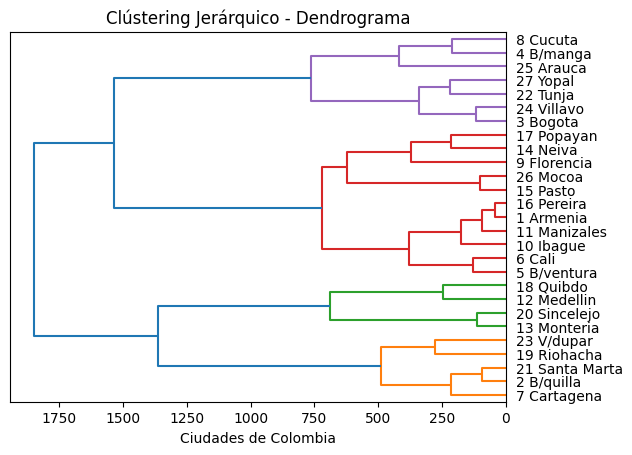

In [6]:
plt.title('Clústering Jerárquico - Dendrograma')
# plot the top three levels of the dendrogram
plot_dendrogram(modelo, truncate_mode='level', labels=nombres.tolist(),orientation='left')
#plot_dendrogram(modelo)
plt.xlabel("Ciudades de Colombia")
plt.show()